## HydroSOS - Persistence and Hydrological Analogues method

In this notebook, we explore the Persistance and Hydrological Analogue method
Firts, we import the python libraries

In [1]:
%reset -f

In [2]:
# Importing the libraries
import pandas as pd
import seaborn as sns
import numpy as np
import calendar
import datetime
import matplotlib.pyplot as plt
plt.style.use('classic')
from scipy.stats.mstats import mquantiles
import os
%matplotlib inline
import locale
import matplotlib.colors as mcolors

from IPython.display import HTML

locale.setlocale(locale.LC_TIME, "es_ES")

sns.set()

In [3]:
alphap = 0.4
betap = 0.4

def quantile_position(x, p, alphap=0.4, betap=0.4):
    # For Weibull use alphap = 0.0 and betap = 0.0. For Cunnane use alphap = 0.4 and betap = 0.4
    return mquantiles(x.dropna(), p, alphap=alphap, betap=betap)[0]

In [4]:
# Quantile Function Definitions
def q1(x):
    return quantile_position(x, 0.28)
def q2(x):   
    return quantile_position(x, 0.50)
def q3(x):   
    return quantile_position(x, 0.72)
def q5(x):   
    return quantile_position(x, 0.05)
def q95(x):  
    return quantile_position(x, 0.95)
def q87(x):  
    return quantile_position(x, 0.87)
def q13(x):  
    return quantile_position(x, 0.13)
def q10(x):  
    return quantile_position(x, 0.10)
def q25(x):  
    return quantile_position(x, 0.25)
def q75(x):  
    return quantile_position(x, 0.75)
def q90(x):  
    return quantile_position(x, 0.90)
def q33(x):
    return quantile_position(x, 0.33)
def q50(x):
    return quantile_position(x, 0.50)
def q66(x):
    return quantile_position(x, 0.66)

We import the monthly discharge data from Fray Marcos station

In [5]:
station_name = '101'
THRESHOLDS = [1715]
input_folder = os.path.join('../stations/data', f'{station_name}.csv')
DISCHARGE_DAILY = pd.read_csv(input_folder,parse_dates=['Fecha'],index_col="Fecha",dayfirst=True,na_values="NA")

In [6]:
# Identify the missing data
DISCHARGE_DAILY_date_missing = pd.date_range(start = DISCHARGE_DAILY.index[0].strftime('%Y-%m-%d'), end = DISCHARGE_DAILY.index[-1].strftime('%Y-%m-%d'),freq='D')
# Re-index the dataframe based on the missind date variable
DISCHARGE_DAILY = DISCHARGE_DAILY.reindex(DISCHARGE_DAILY_date_missing,fill_value=None)
# Set index Fecha
DISCHARGE_DAILY.index.name = 'Date' 
# Change columns names
DISCHARGE_DAILY.columns = ['Discharge']
# Print the last 6 values
HTML(DISCHARGE_DAILY.tail(6).to_html())

,Discharge
Date,
2026-08-26,167.612
2026-08-27,120.881
2026-08-28,148.867
2026-08-29,251.454
2026-08-30,416.887
2026-08-31,341.834


### Plot the results

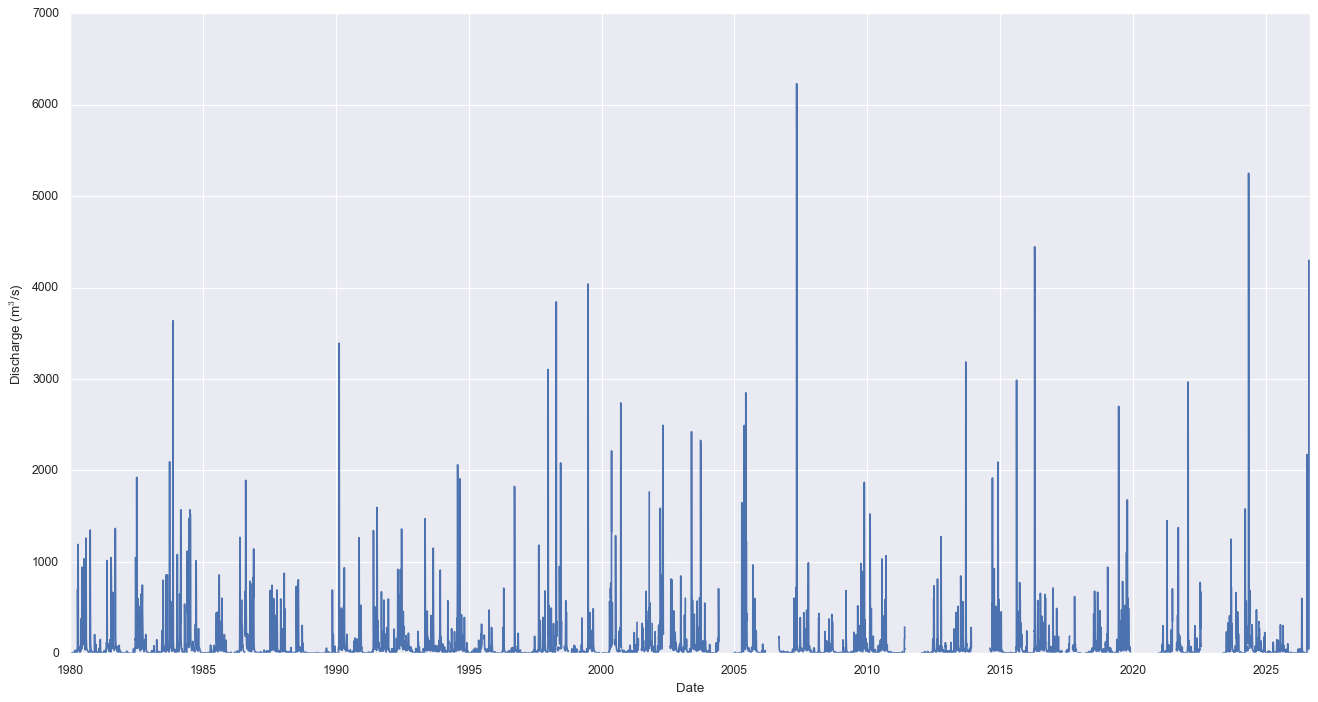

In [7]:
ax1 = DISCHARGE_DAILY['Discharge'].plot(figsize=(20, 10));
ax1.set_xlabel('Date');
ax1.set_ylabel('Discharge (m$^3$/s)');

## Calculate monthly mean from daily data

First, we identify the months which contains lower that 5 null value observation.

In [8]:
# group the Dataframe in a monthly time scale
GROUPER_DISCHARGE_MONTHLY = DISCHARGE_DAILY.groupby(pd.Grouper(freq='1MS'))
NUMBER_MISSING = GROUPER_DISCHARGE_MONTHLY.apply(lambda x: pd.isnull(x).sum()).unstack(1)
# sum the number of null values and assing a "true" if the number of null values are lower that a number for a given month
BOOL_MISSING = GROUPER_DISCHARGE_MONTHLY.apply(lambda x: pd.isnull(x).sum()).unstack(1) < 5
BOOL_MISSING = BOOL_MISSING.to_frame() # convert to DataFrame
BOOL_MISSING.columns = ['missing'] # change the column name to "missing"

NUMBER_MISSING = NUMBER_MISSING.to_frame()
NUMBER_MISSING.columns = ['number_missing'] # change the column name to "missing"

After this, we calculate the monthly mean flow only if the null values in that month are below 5 values

In [9]:
DISCHARGE_MONTHLY = DISCHARGE_DAILY.resample('M').apply(lambda x: x.mean() if x.isnull().sum() < 5 else np.nan)
DISCHARGE_MONTHLY['Year'] = DISCHARGE_MONTHLY.index.year
DISCHARGE_MONTHLY['Month'] = DISCHARGE_MONTHLY.index.month
DISCHARGE_MONTHLY['water_year'] = DISCHARGE_MONTHLY.index.year.where(DISCHARGE_MONTHLY.index.month < 4, DISCHARGE_MONTHLY.index.year + 1)

## create column for day, month, year in the daily discharge ()
DISCHARGE_DAILY['Year'] = DISCHARGE_DAILY.index.year
DISCHARGE_DAILY['Month'] = DISCHARGE_DAILY.index.month
DISCHARGE_DAILY['Day'] = DISCHARGE_DAILY.index.day
DISCHARGE_DAILY['monthday'] = DISCHARGE_DAILY.index.day_of_year
DISCHARGE_DAILY['water_year'] = DISCHARGE_DAILY.index.year.where(DISCHARGE_DAILY.index.month < 4, DISCHARGE_DAILY.index.year + 1)
## 
HTML(DISCHARGE_MONTHLY.head(18).to_html(index=False))
# DISCHARGE_MONTHLY.to_clipboard()

Discharge,Year,Month,water_year
4.194484,1980,1,1980
4.525586,1980,2,1980
12.688516,1980,3,1980
195.164000,1980,4,1981
37.597129,1980,5,1981
310.117033,1980,6,1981
200.092871,1980,7,1981
160.012548,1980,8,1981
12.893267,1980,9,1981
175.533161,1980,10,1981


## Select by Climatology range

First, we transform the discharge to a logaritmic scale and we insert it in the dataframe

In [10]:
DISCHARGE_MONTHLY['Q_to_log'] = np.log(DISCHARGE_MONTHLY['Discharge'])

In [11]:
HTML(DISCHARGE_MONTHLY.tail(6).to_html(index=False))

Discharge,Year,Month,water_year,Q_to_log
NaN,2026,3,2026,NaN
NaN,2026,4,2027,NaN
79.363032,2026,5,2027,4.374033
6.260233,2026,6,2027,1.834217
200.582226,2026,7,2027,5.301224
628.475903,2026,8,2027,6.443298


we plot a Histogram that show the Discharge distribution after the log-transformation

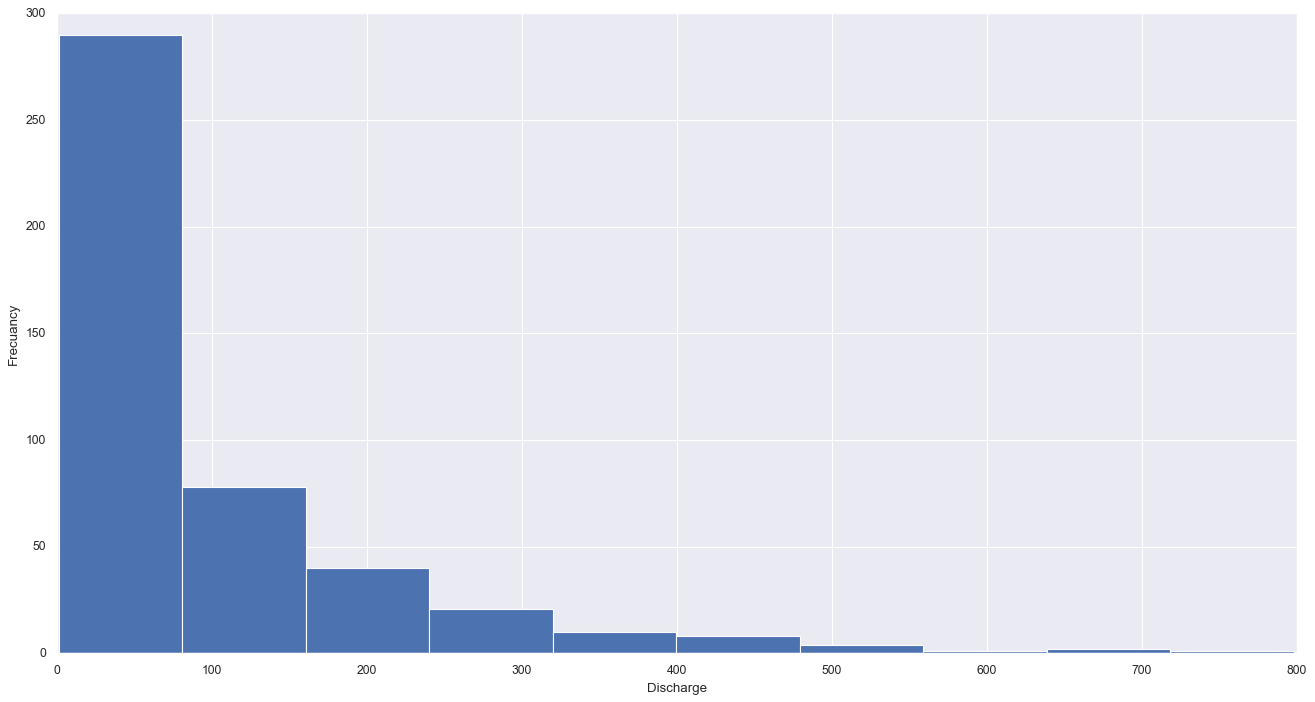

In [12]:
ax2 = DISCHARGE_MONTHLY['Discharge'].hist(figsize=(20, 10));
# ax2.set_xlim(-3.0,3.0)
ax2.set_xlabel('Discharge');
ax2.set_ylabel('Frecuancy');

In this part we select the reference period for analysis. In this case we use the 1991-2020 period

In [13]:
# DISCHARGE_MONTHLY_SELECTED = DISCHARGE_MONTHLY
DISCHARGE_MONTHLY_SELECTED = DISCHARGE_MONTHLY.loc['2004-01-01':'2021-12-31'] # Recent INUMET reference period
HTML(DISCHARGE_MONTHLY_SELECTED.tail(6).to_html(index=False))

Discharge,Year,Month,water_year,Q_to_log
NaN,2021,7,2022,NaN
NaN,2021,8,2022,NaN
274.306600,2021,9,2022,5.614246
49.399000,2021,10,2022,3.899930
NaN,2021,11,2022,NaN
4.722179,2021,12,2022,1.552270


Extract the years from the monthly discharge dataframe

In [14]:
YEAR_SELECTED = np.unique(DISCHARGE_MONTHLY_SELECTED['Year'])
display(YEAR_SELECTED)

array([2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019, 2020, 2021], dtype=int64)

Plot the monthly log Discharge in a BoxPlot Graph

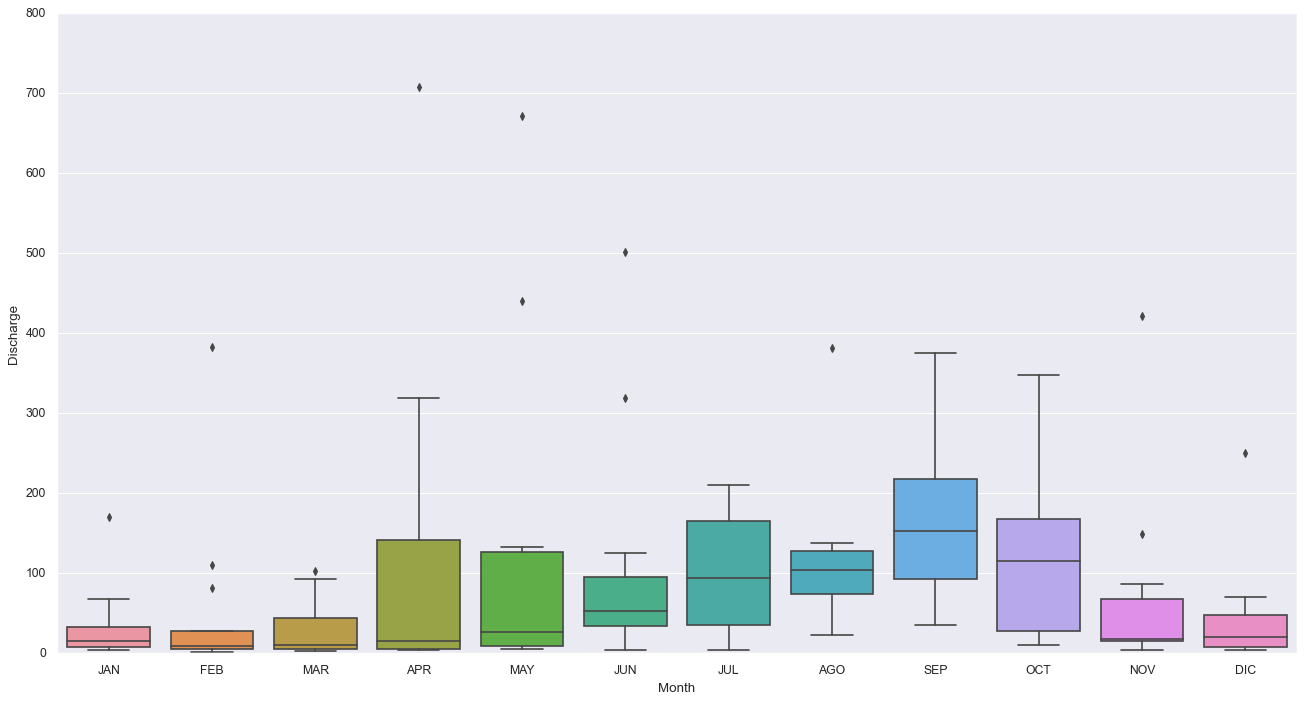

In [15]:
ax3 = plt.figure(figsize=(20, 10))
ax3 = sns.boxplot(data = DISCHARGE_MONTHLY_SELECTED, x='Month', y='Discharge');
ax3.set_xticklabels(['JAN','FEB','MAR','APR','MAY','JUN','JUL','AGO','SEP','OCT','NOV','DIC']);

## Calculate Monthly statistics

In this part we calculate monthly statistcs for the QLog Variable. The statistis include: mean, min, max,25 pct, 50 pct, 75 pct

In [16]:
DISCHARGE_MONTHLY_STATS = DISCHARGE_MONTHLY_SELECTED.Discharge.groupby(DISCHARGE_MONTHLY_SELECTED.index.month).agg([np.min, q10, q33, q25, np.mean, q50, q66, q75, q90, np.max, np.std])
# Display results
# use 
HTML(DISCHARGE_MONTHLY_STATS.to_html())

,amin,q10,q33,q25,mean,q50,q66,q75,q90,amax,std
Date,,,,,,,,,,,
1,3.910742,4.130802,9.635780,7.483400,33.093739,15.272968,25.141559,36.002363,107.366141,170.737581,47.202780
2,2.244607,3.866691,6.059391,5.963314,49.502135,8.926196,23.873959,30.881416,159.639266,382.575214,101.146235
3,3.304645,3.609902,7.192898,4.897697,29.071536,10.824710,36.764885,44.823435,95.744849,103.466129,34.355395
4,3.903933,4.311091,7.653820,5.270567,111.489563,14.869022,52.703584,170.538452,388.905918,708.212633,198.151109
5,4.845290,5.153497,10.520520,8.398487,118.021256,26.539000,59.103719,128.505590,504.781119,671.701065,204.552491
6,4.331633,8.667500,40.875076,30.846463,111.450968,52.517867,80.698132,106.846172,388.847552,501.571033,148.725680
7,4.491935,16.491675,46.087696,34.465021,102.132312,94.038613,155.782139,169.033221,192.799682,210.645742,72.344020
8,23.452355,41.740637,81.820754,69.780826,119.116249,104.630161,119.516906,130.095826,255.029000,381.798290,93.540339
9,35.439867,40.528683,100.889297,90.265762,164.753389,153.264650,199.151594,225.215603,293.411577,375.215433,98.574496


We plot the median, 28th and 72th percentile

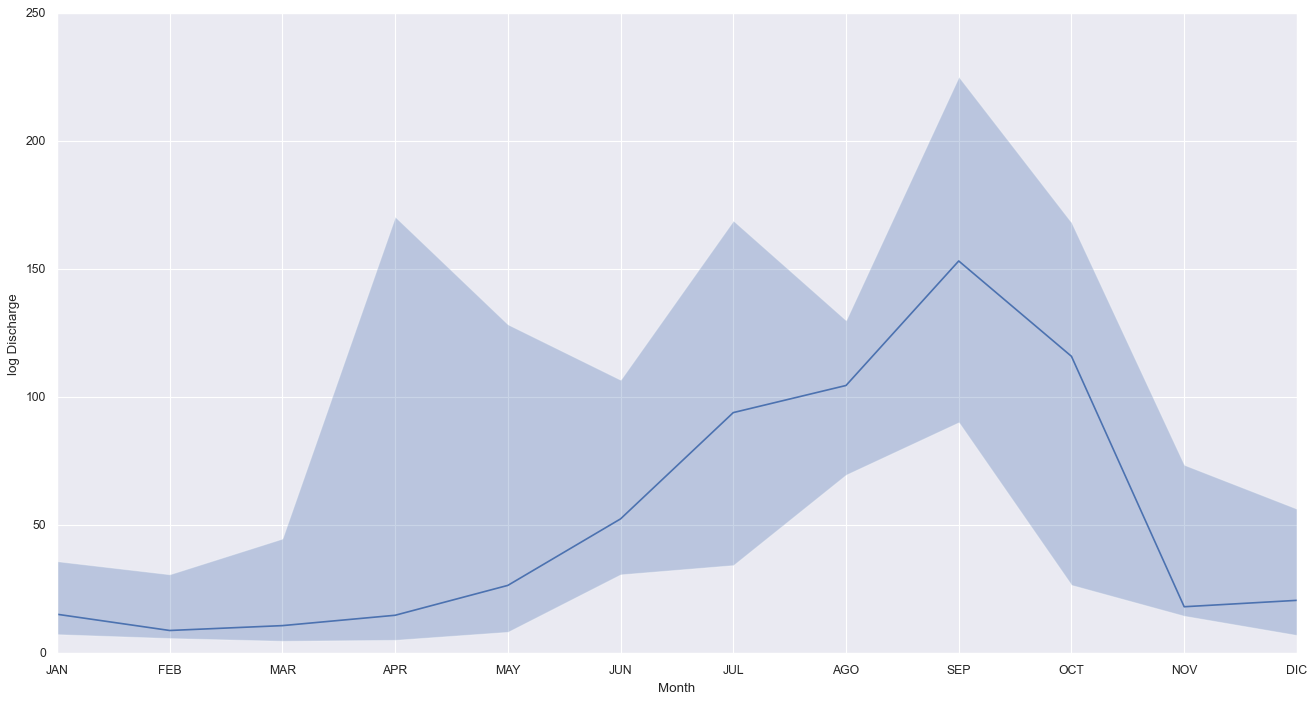

In [17]:
plt.figure(figsize=(20, 10))
plt.plot(DISCHARGE_MONTHLY_STATS.index,DISCHARGE_MONTHLY_STATS['q50'], '-')
# plt.fill_between(monthly_sst.index, monthly_sst['q2'] + monthly_sst['std'], monthly_sst['q2'] - monthly_sst['std'],alpha=0.3)
plt.fill_between(DISCHARGE_MONTHLY_STATS.index, DISCHARGE_MONTHLY_STATS['q25'], DISCHARGE_MONTHLY_STATS['q75'],alpha=0.3)
plt.xlim(1,12)
plt.xticks(DISCHARGE_MONTHLY_STATS.index,labels=['JAN','FEB','MAR','APR','MAY','JUN','JUL','AGO','SEP','OCT','NOV','DIC']);
plt.xlabel('Month');
plt.ylabel('log Discharge');

## Calculate Daily statistics

We reproduce the same procedure for the Daily dataframe

In [18]:
DISCHARGE_DAILY_STATS = DISCHARGE_DAILY.Discharge.groupby(DISCHARGE_DAILY.monthday).agg([np.min, q10, q25, np.mean, q50, q75, q90, np.max, np.std])
HTML(DISCHARGE_DAILY_STATS.head(12).to_html())

,amin,q10,q25,mean,q50,q75,q90,amax,std
monthday,,,,,,,,,
1,1.585,2.67152,4.33810,30.731122,10.1730,28.08030,84.65388,306.221,58.295569
2,1.513,2.63264,4.25870,34.437683,9.7590,26.52550,81.93048,270.630,66.434527
3,1.458,2.59664,4.28950,29.564951,9.0400,31.63260,68.74140,218.920,50.469584
4,1.415,2.58752,4.27690,24.251341,8.4010,32.34570,58.26980,213.153,37.611009
5,1.413,2.52694,3.98550,21.245550,9.5450,28.38335,48.71508,184.842,32.470752
6,1.451,2.19484,3.86200,21.485732,9.0680,25.23990,48.02640,182.648,34.234730
7,1.417,2.11170,3.83090,26.508167,8.2370,23.75770,53.36754,304.989,58.163642
8,1.417,2.04732,3.71675,30.328714,7.8230,21.79935,68.37262,524.349,83.106653
9,1.415,1.98346,3.58960,31.556310,8.3985,20.67165,58.74040,454.897,78.436071


In [19]:
# From DISCHARGE_DAILY extract the year 2026
# year_select = [2026, 1982, 1991, 1997, 2015, 2023]
year_select = [2026, 1991, 1982, 1997, 2015, 2023]
# year_select = [2026,2013,2003]

# Filtrar por la columna 'Year' (año calendario)
DISCHARGE_YEAR_SELECTED = DISCHARGE_DAILY[DISCHARGE_DAILY["Year"].isin(year_select)]
DISCHARGE_YEAR_SELECTED

,Discharge,Year,Month,Day,monthday,water_year
Date,,,,,,
1982-01-01,4.363,1982,1,1,1,1982
1982-01-02,4.209,1982,1,2,2,1982
1982-01-03,4.209,1982,1,3,3,1982
1982-01-04,4.363,1982,1,4,4,1982
1982-01-05,4.057,1982,1,5,5,1982
...,...,...,...,...,...,...
2026-08-27,120.881,2026,8,27,239,2027
2026-08-28,148.867,2026,8,28,240,2027
2026-08-29,251.454,2026,8,29,241,2027


In [20]:
DISCHARGE_DAILY_STATS

,amin,q10,q25,mean,q50,q75,q90,amax,std
monthday,,,,,,,,,
1,1.585,2.67152,4.33810,30.731122,10.173,28.08030,84.65388,306.221,58.295569
2,1.513,2.63264,4.25870,34.437683,9.759,26.52550,81.93048,270.630,66.434527
3,1.458,2.59664,4.28950,29.564951,9.040,31.63260,68.74140,218.920,50.469584
4,1.415,2.58752,4.27690,24.251341,8.401,32.34570,58.26980,213.153,37.611009
5,1.413,2.52694,3.98550,21.245550,9.545,28.38335,48.71508,184.842,32.470752
...,...,...,...,...,...,...,...,...,...
362,1.960,3.33836,4.82220,104.893872,11.144,22.54840,77.00784,3105.257,495.704063
363,1.893,3.03680,5.17080,88.325897,10.683,20.79680,65.61152,2099.900,349.581615
364,1.766,2.83360,4.98700,47.706692,10.285,20.85980,54.33868,748.179,140.888402


In [21]:
# using DISCHARGE_DAILY_STATS, categorize the DISCHARGE_YEAR_SELECTED where p25 and p75 is NORMAL, >p75 is HIGH, <p25 is LOW
DISCHARGE_YEAR_SELECTED = DISCHARGE_YEAR_SELECTED.copy()

# Obtain the corresponding percentile thresholds for each day of the year
q25 = DISCHARGE_YEAR_SELECTED["monthday"].map(DISCHARGE_DAILY_STATS["q25"])
q75 = DISCHARGE_YEAR_SELECTED["monthday"].map(DISCHARGE_DAILY_STATS["q75"])

DISCHARGE_YEAR_SELECTED["category"] = np.select(
    [
        DISCHARGE_YEAR_SELECTED["Discharge"] < q25,
        DISCHARGE_YEAR_SELECTED["Discharge"] > q75,
    ],
    [
        "INFERIOR",
        "SUPERIOR",
    ],
    default="NORMAL",
)

# Preserve missing discharge values as missing categories
DISCHARGE_YEAR_SELECTED.loc[
    DISCHARGE_YEAR_SELECTED["Discharge"].isna(), "category"
] = np.nan


In [22]:
DISCHARGE_YEAR_SELECTED

,Discharge,Year,Month,Day,monthday,water_year,category
Date,,,,,,,
1982-01-01,4.363,1982,1,1,1,1982,NORMAL
1982-01-02,4.209,1982,1,2,2,1982,INFERIOR
1982-01-03,4.209,1982,1,3,3,1982,INFERIOR
1982-01-04,4.363,1982,1,4,4,1982,NORMAL
1982-01-05,4.057,1982,1,5,5,1982,NORMAL
...,...,...,...,...,...,...,...
2026-08-27,120.881,2026,8,27,239,2027,NORMAL
2026-08-28,148.867,2026,8,28,240,2027,SUPERIOR
2026-08-29,251.454,2026,8,29,241,2027,SUPERIOR


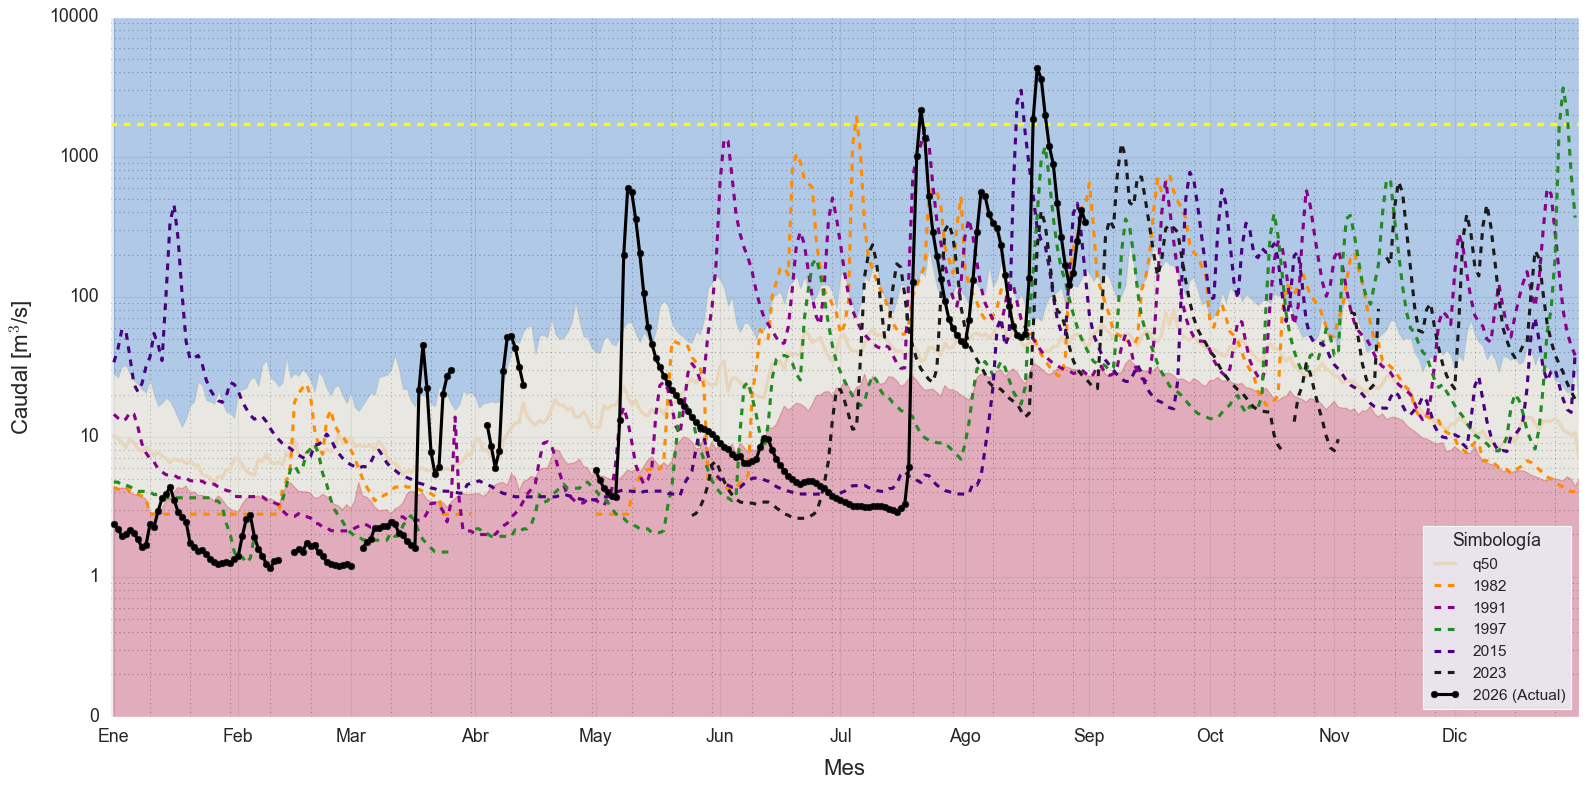

In [23]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


fig, ax = plt.subplots(figsize=(20, 10))

# Curva mediana y bandas de percentiles
ax.plot(
    DISCHARGE_DAILY_STATS.index,
    DISCHARGE_DAILY_STATS["q50"],
    "-",
    color="#E7D6BC",
    linewidth=3.0,
    label="q50",
)
ax.fill_between(
    DISCHARGE_DAILY_STATS.index,
    DISCHARGE_DAILY_STATS["q75"],
    10000,
    alpha=0.3,
    color="#2C7DCD",
)
ax.fill_between(
    DISCHARGE_DAILY_STATS.index,
    DISCHARGE_DAILY_STATS["q25"],
    DISCHARGE_DAILY_STATS["q75"],
    alpha=0.3,
    color="#E7E2BC",
)
ax.fill_between(
    DISCHARGE_DAILY_STATS.index,
    0,
    DISCHARGE_DAILY_STATS["q25"],
    alpha=0.3,
    color="#CD233F",
)

# Paleta de alto contraste (evita azules/rojos/beige ya usados en las bandas) y variación de estilo de línea

CONTRAST_COLORS = [
    "#FF8C00",  # naranja oscuro
    "#8B008B",  # magenta oscuro
    "#228B22",  # verde bosque
    "#4B0082",  # índigo
    "#1B1B1B",  # turquesa oscuro
    "#8B4513",  # marrón silla
    "#FF1493",  # rosa profundo
    "#556B2F",  # oliva oscuro
    "#9400D3",  # violeta oscuro
    "#1B1B1B",  # casi negro
]

CONTRAST_LINESTYLES = ["--", "-.", ":", (0, (3, 1, 1, 1))]

years_list = sorted(y for y in DISCHARGE_YEAR_SELECTED["Year"].unique() if y != 2026)
year_color_map = {year: CONTRAST_COLORS[i % len(CONTRAST_COLORS)] for i, year in enumerate(years_list)}
year_linestyle_map = {
    year: CONTRAST_LINESTYLES[(i // len(CONTRAST_COLORS)) % len(CONTRAST_LINESTYLES)]
    for i, year in enumerate(years_list)
}

# Iterar y graficar cada año
for year, group in DISCHARGE_YEAR_SELECTED.groupby("Year"):
    if year == 2026:
        ax.plot(
            group["monthday"],
            group["Discharge"],
            label=f"{year} (Actual)",
            color="black",
            linewidth=2.8,
            alpha=1.0,
            zorder=5,
            # add marker with a circle and fill color white
            marker="o",
            markerfacecolor="black",
        )
    else:

        ax.plot(
            group["monthday"],
            group["Discharge"],
            label=str(year),
            color=year_color_map.get(year),
            linewidth=2.8,
            linestyle=year_linestyle_map.get(year),
            alpha=1.0,
            zorder=3,
        )

# -------------------------------------------------------------
# Configuración del eje X con nombres de Meses
# -------------------------------------------------------------
month_names = {
    1: "Ene",
    2: "Feb",
    3: "Mar",
    4: "Abr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dic",
}
month_ticks = (
    DISCHARGE_YEAR_SELECTED.drop_duplicates(subset=["Month"])
    .sort_values("monthday")[["Month", "monthday"]]
    .copy()
)
month_positions = month_ticks["monthday"].values
month_labels = [month_names[m] for m in month_ticks["Month"].values]

ax.set_xlim(1, 366)
ax.set_xticks(month_positions)
ax.set_xticklabels(month_labels, fontsize=16, fontweight="normal")
ax.set_xticks(np.arange(0, 366, 10.0), minor=True)

# -------------------------------------------------------------
# Escala Logarítmica y Formato Numérico Estándar (Eje Y)
# -------------------------------------------------------------
ax.set_yscale("log")

# Forzar formato decimal normal (0, 1, 10, 100, 1000...)
formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)

# Tamaños de texto
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16, which="both")

ax.set_xlabel("Mes", fontsize=20, labelpad=12, fontweight="normal")
# ax.set_ylabel("Nivel [m]", fontsize=20, labelpad=12, fontweight="normal")
ax.set_ylabel("Caudal [m$^3$/s]", fontsize=20, labelpad=12, fontweight="normal")

# Leyenda
ax.legend(
    title="Simbología",
    title_fontsize=16,
    fontsize=14,
    loc="lower right",
    framealpha=0.9,
)
# ax.title(f'Caudales registrados en ', {str(station_name)})
# Rejilla
ax.grid(True, which="major", linestyle="-", color="#d0d0d0", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", color="#1b1b1b", alpha=0.4)

# -------------------------------------------------------------
# Thresholds values
# -------------------------------------------------------------
# add a horizontal line for each threshold
# add something if there isnt a threshold variable
if not THRESHOLDS:  # default threshold value
    THRESHOLDS = [1]
else:
    for threshold_value in THRESHOLDS:
        ax.axhline(
            y=threshold_value,
            # for the first threshold, use yellow and the second is red
            color="yellow" if threshold_value == THRESHOLDS[0] else "red",
            linestyle="--",
            linewidth=3.0,
            alpha=1,
            zorder=2,
        )

# set min to 1
ax.set_ylim(bottom=0.1)

plt.tight_layout()
plt.show()


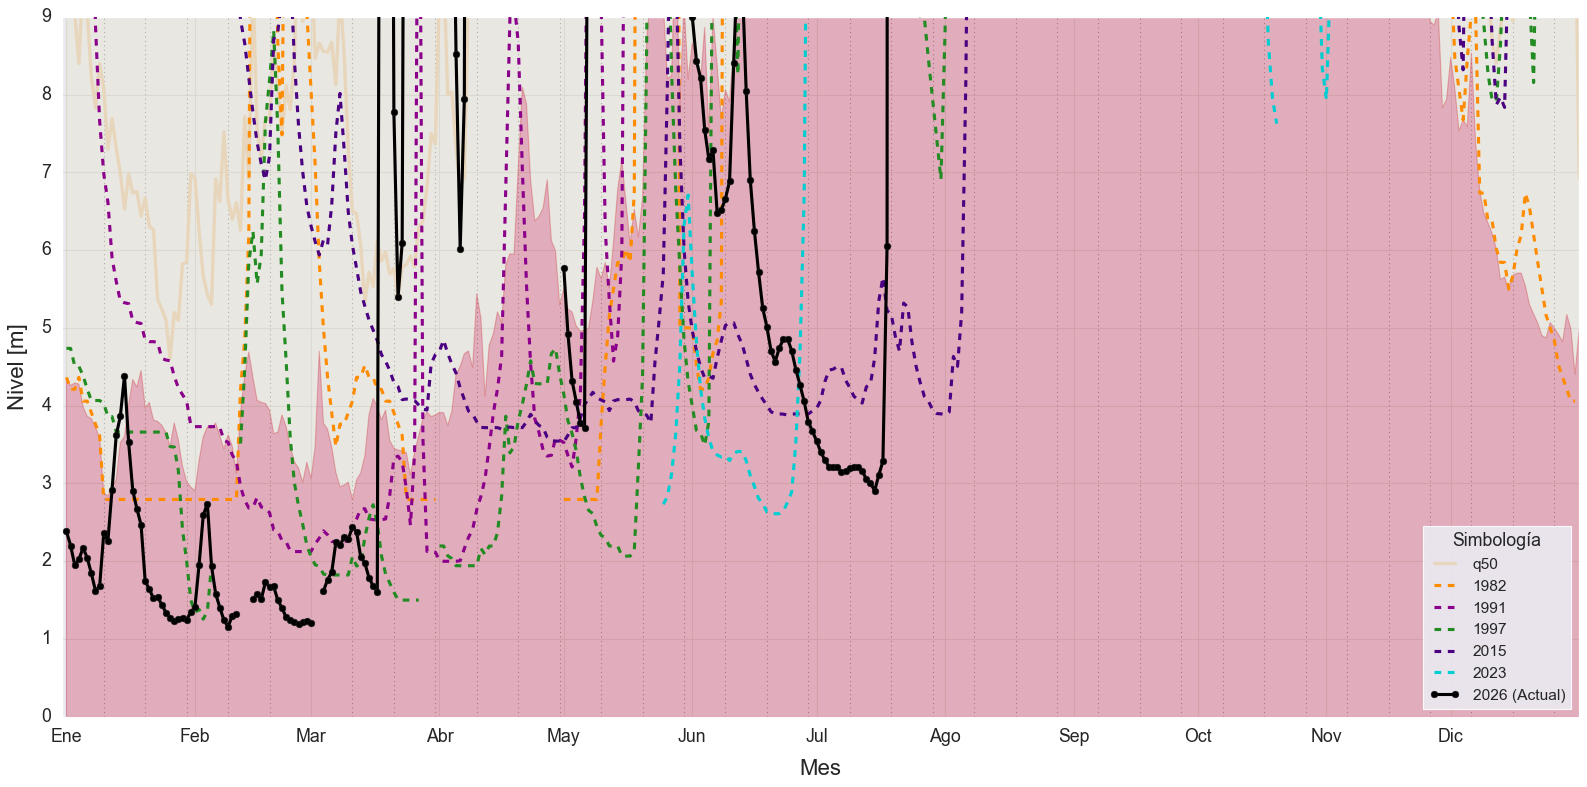

In [24]:
fig, ax = plt.subplots(figsize=(20, 10))

# Curva mediana y bandas de percentiles
ax.plot(
    DISCHARGE_DAILY_STATS.index,
    DISCHARGE_DAILY_STATS["q50"],
    "-",
    color="#E7D6BC",
    linewidth=3.0,
    label="q50",
)
ax.fill_between(
    DISCHARGE_DAILY_STATS.index,
    DISCHARGE_DAILY_STATS["q75"],
    10,
    alpha=0.3,
    color="#2C7DCD",
)
ax.fill_between(
    DISCHARGE_DAILY_STATS.index,
    DISCHARGE_DAILY_STATS["q25"],
    DISCHARGE_DAILY_STATS["q75"],
    alpha=0.3,
    color="#E7E2BC",
)
ax.fill_between(
    DISCHARGE_DAILY_STATS.index,
    0,
    DISCHARGE_DAILY_STATS["q25"],
    alpha=0.3,
    color="#CD233F",
)

# Paleta de alto contraste (evita azules/rojos/beige ya usados en las bandas) y variación de estilo de línea
CONTRAST_COLORS = [
    "#FF8C00",  # naranja oscuro
    "#8B008B",  # magenta oscuro
    "#228B22",  # verde bosque
    "#4B0082",  # índigo
    "#00CED1",  # turquesa oscuro
    "#8B4513",  # marrón silla
    "#FF1493",  # rosa profundo
    "#556B2F",  # oliva oscuro
    "#9400D3",  # violeta oscuro
    "#1B1B1B",  # casi negro
]
CONTRAST_LINESTYLES = ["--", "-.", ":", (0, (3, 1, 1, 1))]

years_list = sorted(y for y in DISCHARGE_YEAR_SELECTED["Year"].unique() if y != 2026)
year_color_map = {year: CONTRAST_COLORS[i % len(CONTRAST_COLORS)] for i, year in enumerate(years_list)}
year_linestyle_map = {
    year: CONTRAST_LINESTYLES[(i // len(CONTRAST_COLORS)) % len(CONTRAST_LINESTYLES)]
    for i, year in enumerate(years_list)
}

# Iterar y graficar cada año
for year, group in DISCHARGE_YEAR_SELECTED.groupby("Year"):
    if year == 2026:
        ax.plot(
            group["monthday"],
            group["Discharge"],
            label=f"{year} (Actual)",
            color="black",
            linewidth=2.8,
            alpha=1.0,
            zorder=5,
            # add marker with a circle and fill color white
            marker="o",
            markerfacecolor="black",
        )
    else:
        ax.plot(
            group["monthday"],
            group["Discharge"],
            label=str(year),
            color=year_color_map.get(year),
            linewidth=2.8,
            linestyle=year_linestyle_map.get(year),
            alpha=1.0,
            zorder=3,
        )

# -------------------------------------------------------------
# Configuración del eje X con nombres de Meses
# -------------------------------------------------------------
month_names = {
    1: "Ene",
    2: "Feb",
    3: "Mar",
    4: "Abr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dic",
}

month_ticks = (
    DISCHARGE_YEAR_SELECTED.drop_duplicates(subset=["Month"])
    .sort_values("monthday")[["Month", "monthday"]]
    .copy()
)
month_positions = month_ticks["monthday"].values
month_labels = [month_names[m] for m in month_ticks["Month"].values]

ax.set_xlim(1, 366)
ax.set_xticks(month_positions)
ax.set_xticklabels(month_labels, fontsize=16, fontweight="normal")
ax.set_xticks(np.arange(0, 366, 10.0), minor=True)

# -------------------------------------------------------------
# Escala Logarítmica y Formato Numérico Estándar (Eje Y)
# -------------------------------------------------------------
# ax.set_yscale("log")

# Forzar formato decimal normal (0, 1, 10, 100, 1000...)
formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)

# Tamaños de texto
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16, which="both")

ax.set_ylim(0, 9)

ax.set_xlabel("Mes", fontsize=20, labelpad=12, fontweight="normal")
ax.set_ylabel("Nivel [m]", fontsize=20, labelpad=12, fontweight="normal")
# ax.set_ylabel("Caudal [m$^3$/s]", fontsize=20, labelpad=12, fontweight="normal")

# Leyenda
ax.legend(
    title="Simbología",
    title_fontsize=16,
    fontsize=14,
    loc="lower right",
    framealpha=0.9,
)
# ax.title(f'Caudales registrados en ', {str(station_name)})
# Rejilla
ax.grid(True, which="major", linestyle="-", color="#d0d0d0", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", color="#1b1b1b", alpha=0.4)

plt.tight_layout()
plt.show()


#### heatmap


In [25]:
percentile = [0.10, 0.25, 0.75, 0.90]
values = ['High flow','Above normal','Normal range','Below normal','Low flow']
flow_cat = [5,4,3,2,1]
alphap = 0.4
betap = 0.4

stdStart = 1981
stdEnd = 2010

In [26]:
def _classify(df):
    wr = df['pct_rank']
    criteria = [
        (wr >= percentile[3]) & (wr <= 1.00),
        (wr > percentile[2]) & (wr < percentile[3]),
        (wr >= percentile[1]) & (wr <= percentile[2]),
        (wr >= percentile[0]) & (wr < percentile[1]),
        (wr >= 0.00) & (wr < percentile[0]),
    ]
    df['percentile_range'] = np.select(criteria, values, None)
    df['flowcat'] = np.select(criteria, flow_cat, pd.NA)

def _compute_status(df, group_col, avg_series, anomaly_col,alphap,betap):
    avg_map = df[group_col].map(avg_series)
    df[anomaly_col] = (df['Discharge'] - avg_map) / avg_map
    df['rank_average'] = df.groupby(group_col)['Discharge'].rank()
    df['complete%'] = df.groupby(group_col)['Discharge'].transform(lambda x: x.notnull().sum())
    df['pct_rank'] = (df['rank_average'] - alphap) / (df['complete%'] + 1 - alphap - betap)
    _classify(df)

def daily_status(DISCHARGE_DAILY):
    avg = DISCHARGE_DAILY[
        (DISCHARGE_DAILY['Year'] >= stdStart) & (DISCHARGE_DAILY['Year'] <= stdEnd)
    ].groupby('monthday')['Discharge'].mean()

    df = DISCHARGE_DAILY.copy()
    _compute_status(df, 'monthday', avg, 'percentile_flow', alphap=alphap, betap=betap)
    return df

In [27]:
df_status = daily_status(DISCHARGE_DAILY)

In [28]:
# Filtrar por la columna 'Year' (año calendario)
df_status_selected = df_status[df_status["Year"].isin(year_select)]
df_status_selected

,Discharge,Year,Month,Day,monthday,water_year,percentile_flow,rank_average,complete%,pct_rank,percentile_range,flowcat
Date,,,,,,,,,,,,
1982-01-01,4.363,1982,1,1,1,1982,-0.878394,11.0,41,0.257282,Normal range,3
1982-01-02,4.209,1982,1,2,2,1982,-0.881759,10.0,41,0.233010,Below normal,2
1982-01-03,4.209,1982,1,3,3,1982,-0.855193,10.0,41,0.233010,Below normal,2
1982-01-04,4.363,1982,1,4,4,1982,-0.824213,11.0,41,0.257282,Normal range,3
1982-01-05,4.057,1982,1,5,5,1982,-0.816469,11.0,40,0.263682,Normal range,3
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-27,120.881,2026,8,27,239,2027,0.470173,30.0,41,0.718447,Normal range,3
2026-08-28,148.867,2026,8,28,240,2027,0.456219,33.0,41,0.791262,Above normal,4
2026-08-29,251.454,2026,8,29,241,2027,1.241158,36.0,41,0.864078,Above normal,4


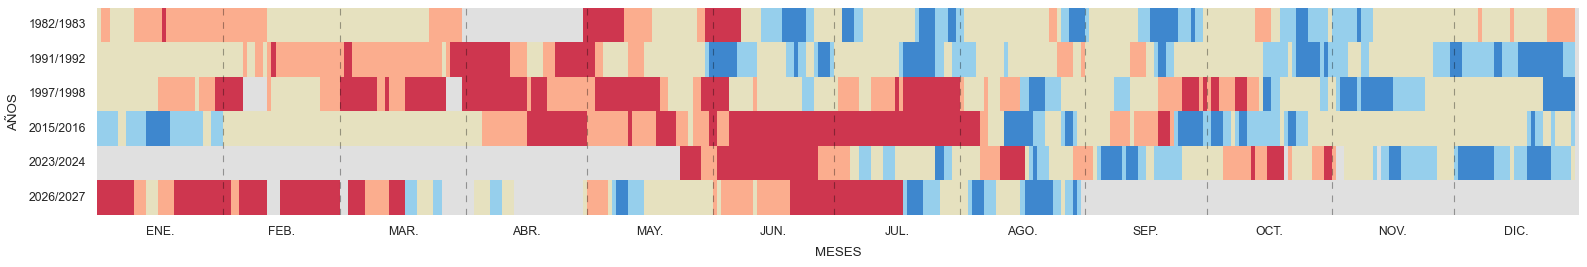

In [29]:
# 1. Preparar DataFrame
df_plot = df_status_selected.copy()
if "Date" not in df_plot.columns and df_plot.index.name == "Date":
    df_plot = df_plot.reset_index()

# Convertir flowcat a numérico compatible con NaN
df_plot["flowcat"] = pd.to_numeric(df_plot["flowcat"], errors="coerce")

# 2. Pivotar la tabla usando 'flowcat' asegurando el rango completo de días (1 a 366)
heatmap_values = df_plot.pivot(
    index="Year", columns="monthday", values="flowcat"
).sort_index().reindex(columns=np.arange(1, 367))

# 3. Configurar mapa de colores discretos (1 a 5) y gris claro para NaN
colors = ["#CD233F", "#FFA885", "#E7E2BC", "#8ECEEE", "#2C7DCD"]
bounds = [1, 2, 3, 4, 5, 6]
cmap = mcolors.ListedColormap(colors)
cmap.set_bad(color="#E0E0E0")  # Gris claro para datos faltantes
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# 4. Graficar heatmap
plt.figure(figsize=(20, 3.5))

ax = sns.heatmap(
    heatmap_values,
    cmap=cmap,
    norm=norm,
    annot=False,
    fmt="",
    linewidths=0.0,
    cbar=False,
    square=False,
    alpha=0.9,
)
ax.set_facecolor("#E0E0E0")  # Fondo gris para celdas vacías

# 5. Configurar etiquetas del eje Y con formato "YYYY/YYYY+1"
year_labels = [f"{int(y)}/{int(y) + 1}" for y in heatmap_values.index]
ax.set_yticks(np.arange(len(heatmap_values.index)) + 0.5)
ax.set_yticklabels(year_labels, rotation=0, fontsize=11)

# 6. Configurar etiquetas de meses centradas en el eje X y líneas divisorias
plt.xlabel("MESES", fontsize=12, labelpad=8)
plt.ylabel("AÑOS", fontsize=12, labelpad=8)

# Plantilla calendario de 366 días para alinear exactamente cada mes
ref_dates = pd.date_range("2024-01-01", "2024-12-31", freq="D")
df_cal = pd.DataFrame({
    "month": ref_dates.month,
    "col_idx": np.arange(len(ref_dates))  # Coordenadas 0 a 365 de las columnas
})

month_ticks = []
month_labels = []

for m, group in df_cal.groupby("month", sort=True):
    start_pos = group["col_idx"].min()
    end_pos = group["col_idx"].max()

    # Centro exacto de los días correspondientes a ese mes
    mid_point = (start_pos + end_pos + 1) / 2.0
    month_ticks.append(mid_point)
    month_labels.append(calendar.month_abbr[m].upper())

    # Línea divisoria gris vertical al inicio de cada mes (desde febrero en adelante)
    if m > 1:
        ax.axvline(start_pos, color="black", linewidth=1.0, linestyle="--", alpha=0.35)

ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels, rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

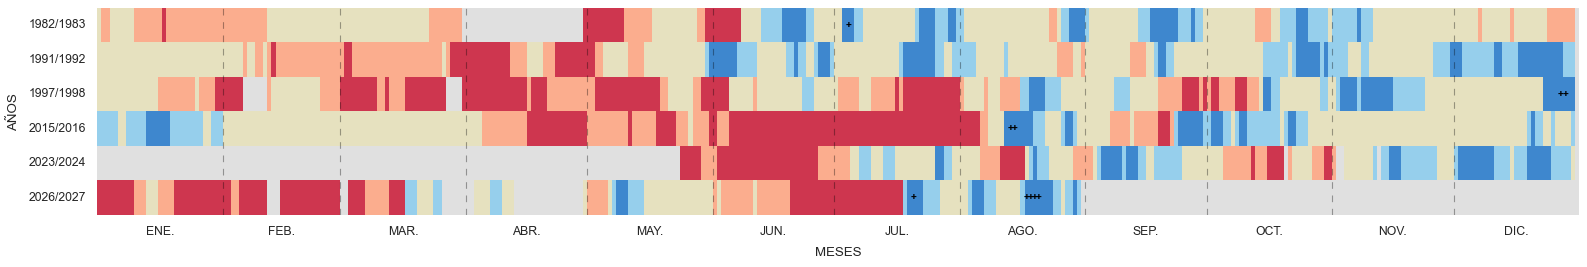

In [30]:
# ---------------------------------------------------------
# 1. Preparar DataFrame de trabajo (aislado mediante .copy())
# ---------------------------------------------------------
df_plot = df_status_selected.copy()
if "Date" not in df_plot.columns and df_plot.index.name == "Date":
    df_plot = df_plot.reset_index()

# Asegurar tipo numérico en columnas clave
df_plot["Discharge"] = pd.to_numeric(df_plot["Discharge"], errors="coerce")
df_plot["flowcat"] = pd.to_numeric(df_plot["flowcat"], errors="coerce")

# ---------------------------------------------------------
# 2. Pivotar datos base para el mapa de calor (flowcat)
# ---------------------------------------------------------
# Se asegura reindexar de 1 a 366 para mantener dimensiones consistentes
heatmap_values = df_plot.pivot(
    index="Year", columns="monthday", values="flowcat"
).sort_index().reindex(columns=np.arange(1, 367))

# ---------------------------------------------------------
# 3. Validación de umbral y generación de anotaciones
# ---------------------------------------------------------
has_valid_threshold = bool(
    THRESHOLDS
    and len(THRESHOLDS) > 0
    and THRESHOLDS[0] is not None
    and THRESHOLDS[0] > -999
)

if has_valid_threshold:
    threshold_val = THRESHOLDS[0]
    df_plot["exceeds_threshold"] = (
        df_plot["Discharge"] >= threshold_val
    ).astype(int)

    annot_matrix = (
        df_plot.pivot(
            index="Year", columns="monthday", values="exceeds_threshold"
        )
        .sort_index()
        .reindex(columns=np.arange(1, 367))
        == 1
    )
    annot_param = np.where(annot_matrix, "+", "")
    annot_kws = {"size": 9, "weight": "bold", "color": "black"}
else:
    annot_param = False
    annot_kws = None

# ---------------------------------------------------------
# 4. Configurar paleta de colores discretos (flowcat 1 a 5) y NaN
# ---------------------------------------------------------
colors = ["#CD233F", "#FFA885", "#E7E2BC", "#8ECEEE", "#2C7DCD"]
bounds = [1, 2, 3, 4, 5, 6]
cmap = mcolors.ListedColormap(colors)
cmap.set_bad(color="#E0E0E0")  # Gris claro para datos faltantes (NaN)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# ---------------------------------------------------------
# 5. Graficar heatmap
# ---------------------------------------------------------
plt.figure(figsize=(20, 3.5))

ax = sns.heatmap(
    heatmap_values,
    cmap=cmap,
    norm=norm,
    annot=annot_param,
    fmt="",
    annot_kws=annot_kws,
    linewidths=0.0,
    cbar=False,
    square=False,
    alpha=0.9,
)
ax.set_facecolor("#E0E0E0")  # Fondo gris para celdas nulas

# ---------------------------------------------------------
# 6. Formato de ejes y separadores mensuales
# ---------------------------------------------------------
# Eje Y: formato "YYYY/YYYY+1" (ej: "1982/1983", "2026/2027")
year_labels = [f"{int(y)}/{int(y) + 1}" for y in heatmap_values.index]
ax.set_yticks(np.arange(len(heatmap_values.index)) + 0.5)
ax.set_yticklabels(year_labels, rotation=0, fontsize=11)

plt.xlabel("MESES", fontsize=12, labelpad=8)
plt.ylabel("AÑOS", fontsize=12, labelpad=8)

# Eje X: Centrado exacto por días de calendario (año bisiesto base) y líneas verticales
ref_dates = pd.date_range("2024-01-01", "2024-12-31", freq="D")
df_cal = pd.DataFrame({
    "month": ref_dates.month,
    # En Seaborn las columnas van de 0 a (len-1) a nivel de coordenadas de ejes
    "col_idx": np.arange(len(ref_dates))
})

month_ticks = []
month_labels = []

for m, group in df_cal.groupby("month", sort=True):
    start_pos = group["col_idx"].min()
    end_pos = group["col_idx"].max()

    # Punto medio exacto del mes
    mid_point = (start_pos + end_pos + 1) / 2.0
    month_ticks.append(mid_point)
    month_labels.append(calendar.month_abbr[m].upper())

    # Línea vertical divisoria al inicio de cada mes (a partir de febrero)
    if m > 1:
        ax.axvline(start_pos, color="black", linewidth=1.0, linestyle="--", alpha=0.35)

ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels, rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

In [31]:
def plot_event_heatmap(
    df,
    years_event,
    start_month=8,
    end_month=7,
    cross_year=None,
    thresholds=None,
    flowcat_col="flowcat",
    discharge_col="Discharge",
    date_col="Date",
    figsize=(20, 4),
):
    """Genera un heatmap comparativo de eventos hidrológicos entre meses personalizados."""
    # 1. Preparar datos base
    df_base = df.copy()
    if date_col not in df_base.columns and df_base.index.name == date_col:
        df_base = df_base.reset_index()

    df_base[date_col] = pd.to_datetime(df_base[date_col])
    df_base[discharge_col] = pd.to_numeric(
        df_base[discharge_col], errors="coerce"
    )
    df_base[flowcat_col] = pd.to_numeric(df_base[flowcat_col], errors="coerce")

    # 2. Determinar si el ciclo cruza al año siguiente
    if cross_year is None:
        is_cross_year = start_month >= end_month
    else:
        is_cross_year = cross_year

    # 3. Construir la plantilla de referencia usando un ciclo bisiesto (2023-2024)
    ref_y_start = 2023
    ref_y_end = 2024 if is_cross_year else 2023

    last_day_end = calendar.monthrange(ref_y_end, end_month)[1]
    t_ref_start = pd.Timestamp(year=ref_y_start, month=start_month, day=1)
    t_ref_end = pd.Timestamp(year=ref_y_end, month=end_month, day=last_day_end)

    ref_dates = pd.date_range(t_ref_start, t_ref_end, freq="D")
    ref_template = pd.DataFrame(
        {
            "rel_date": ref_dates,
            "month": ref_dates.month,
            "day": ref_dates.day,
            "day_idx": np.arange(len(ref_dates)),
        }
    )

    # 4. Filtrar y alinear períodos para cada año
    years_sorted = sorted(years_event)
    frames = []

    for yr in years_sorted:
        yr_end = yr + 1 if is_cross_year else yr
        last_day = calendar.monthrange(yr_end, end_month)[1]

        t_start = pd.Timestamp(year=yr, month=start_month, day=1)
        t_end = pd.Timestamp(year=yr_end, month=end_month, day=last_day)

        sub = df_base[
            (df_base[date_col] >= t_start) & (df_base[date_col] <= t_end)
        ].copy()
        if not sub.empty:
            sub["event_year"] = yr
            sub["day_idx"] = (sub[date_col] - t_start).dt.days
            frames.append(sub)

    if not frames:
        raise ValueError(
            "No se encontraron registros para los períodos especificados."
        )

    df_plot = pd.concat(frames, ignore_index=True)

    # 5. Pivotar matriz principal (flowcat)
    heatmap_values = df_plot.pivot(
        index="event_year", columns="day_idx", values=flowcat_col
    ).reindex(index=years_sorted, columns=np.arange(len(ref_template)))

    # 6. Matriz de umbrales
    has_valid_threshold = bool(
        thresholds
        and len(thresholds) > 0
        and thresholds[0] is not None
        and thresholds[0] > -999
    )

    if has_valid_threshold:
        df_plot["exceeds_threshold"] = (
            df_plot[discharge_col] >= thresholds[0]
        ).astype(int)
        annot_matrix = (
            df_plot.pivot(
                index="event_year",
                columns="day_idx",
                values="exceeds_threshold",
            ).reindex(index=years_sorted, columns=np.arange(len(ref_template)))
            == 1
        )
        annot_param = np.where(annot_matrix, "+", "")
        annot_kws = {"size": 9, "weight": "bold", "color": "black"}
    else:
        annot_param = False
        annot_kws = None

    # 7. Paleta discreta de colores (1 a 5) + color para NaN (Gris claro)
    colors = ["#CD233F", "#FFA885", "#E7E2BC", "#8ECEEE", "#2C7DCD"]
    bounds = [1, 2, 3, 4, 5, 6]
    cmap = mcolors.ListedColormap(colors)
    cmap.set_bad(color="#E0E0E0")  # Gris claro para datos faltantes
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # 8. Graficar Heatmap
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor("#E0E0E0")  # Fondo gris para celdas vacías

    sns.heatmap(
        heatmap_values,
        cmap=cmap,
        norm=norm,
        annot=annot_param,
        fmt="",
        annot_kws=annot_kws,
        linewidths=0.0,
        cbar=False,
        square=False,
        alpha=0.9,
        ax=ax,
    )

    # 9. Configuración de etiquetas del eje Y
    if is_cross_year:
        year_labels = [f"{int(y)}/{int(y) + 1}" for y in heatmap_values.index]
    else:
        year_labels = [str(int(y)) for y in heatmap_values.index]

    ax.set_yticks(np.arange(len(heatmap_values.index)) + 0.5)
    ax.set_yticklabels(year_labels, rotation=0, fontsize=11)

    # 10. Configuración de etiquetas del eje X y separadores mensuales
    month_ticks = []
    month_labels = []

    ref_template["period_block"] = ref_template["rel_date"].dt.to_period("M")
    first_block = True

    for period, group in ref_template.groupby("period_block", sort=False):
        min_idx = group["day_idx"].min()
        max_idx = group["day_idx"].max()

        # Posición central del mes para el label
        mid_point = (min_idx + max_idx) / 2.0
        month_ticks.append(mid_point)
        month_labels.append(calendar.month_abbr[period.month].upper())

        # Líneas verticales grises divisorias entre meses
        if not first_block:
            ax.axvline(
                min_idx, color="black", linewidth=1.0, linestyle="--", alpha=0.35
            )
        first_block = False

    ax.set_xticks(month_ticks)
    ax.set_xticklabels(month_labels, rotation=0, fontsize=11)

    ax.set_xlabel("MESES", fontsize=12, labelpad=8)
    ax.set_ylabel(
        "PERÍODO DEL EVENTO" if is_cross_year else "AÑO",
        fontsize=12,
        labelpad=8,
    )

    plt.tight_layout()
    return fig, ax

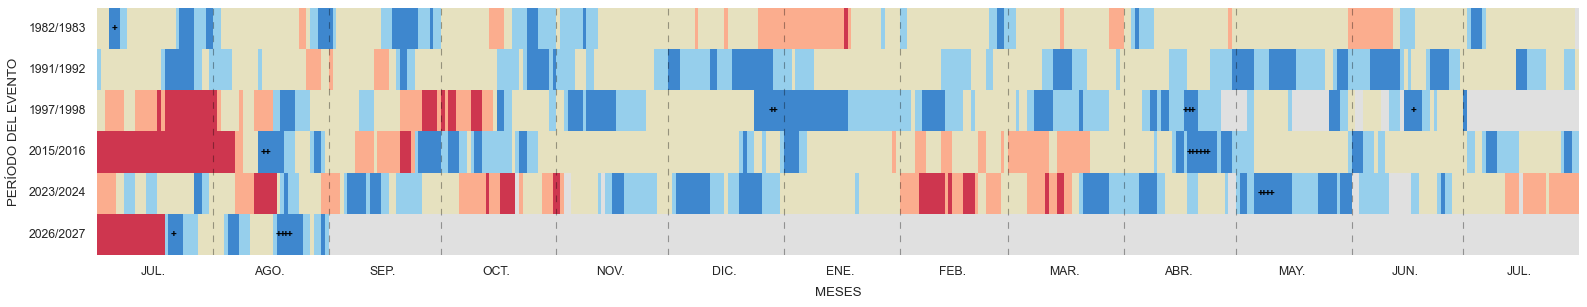

In [32]:
fig, ax = plot_event_heatmap(
    df=df_status,
    years_event=[2026, 1991, 1982, 1997, 2015, 2023],
    start_month=7,
    end_month=7,
    thresholds=THRESHOLDS,
)
plt.show()

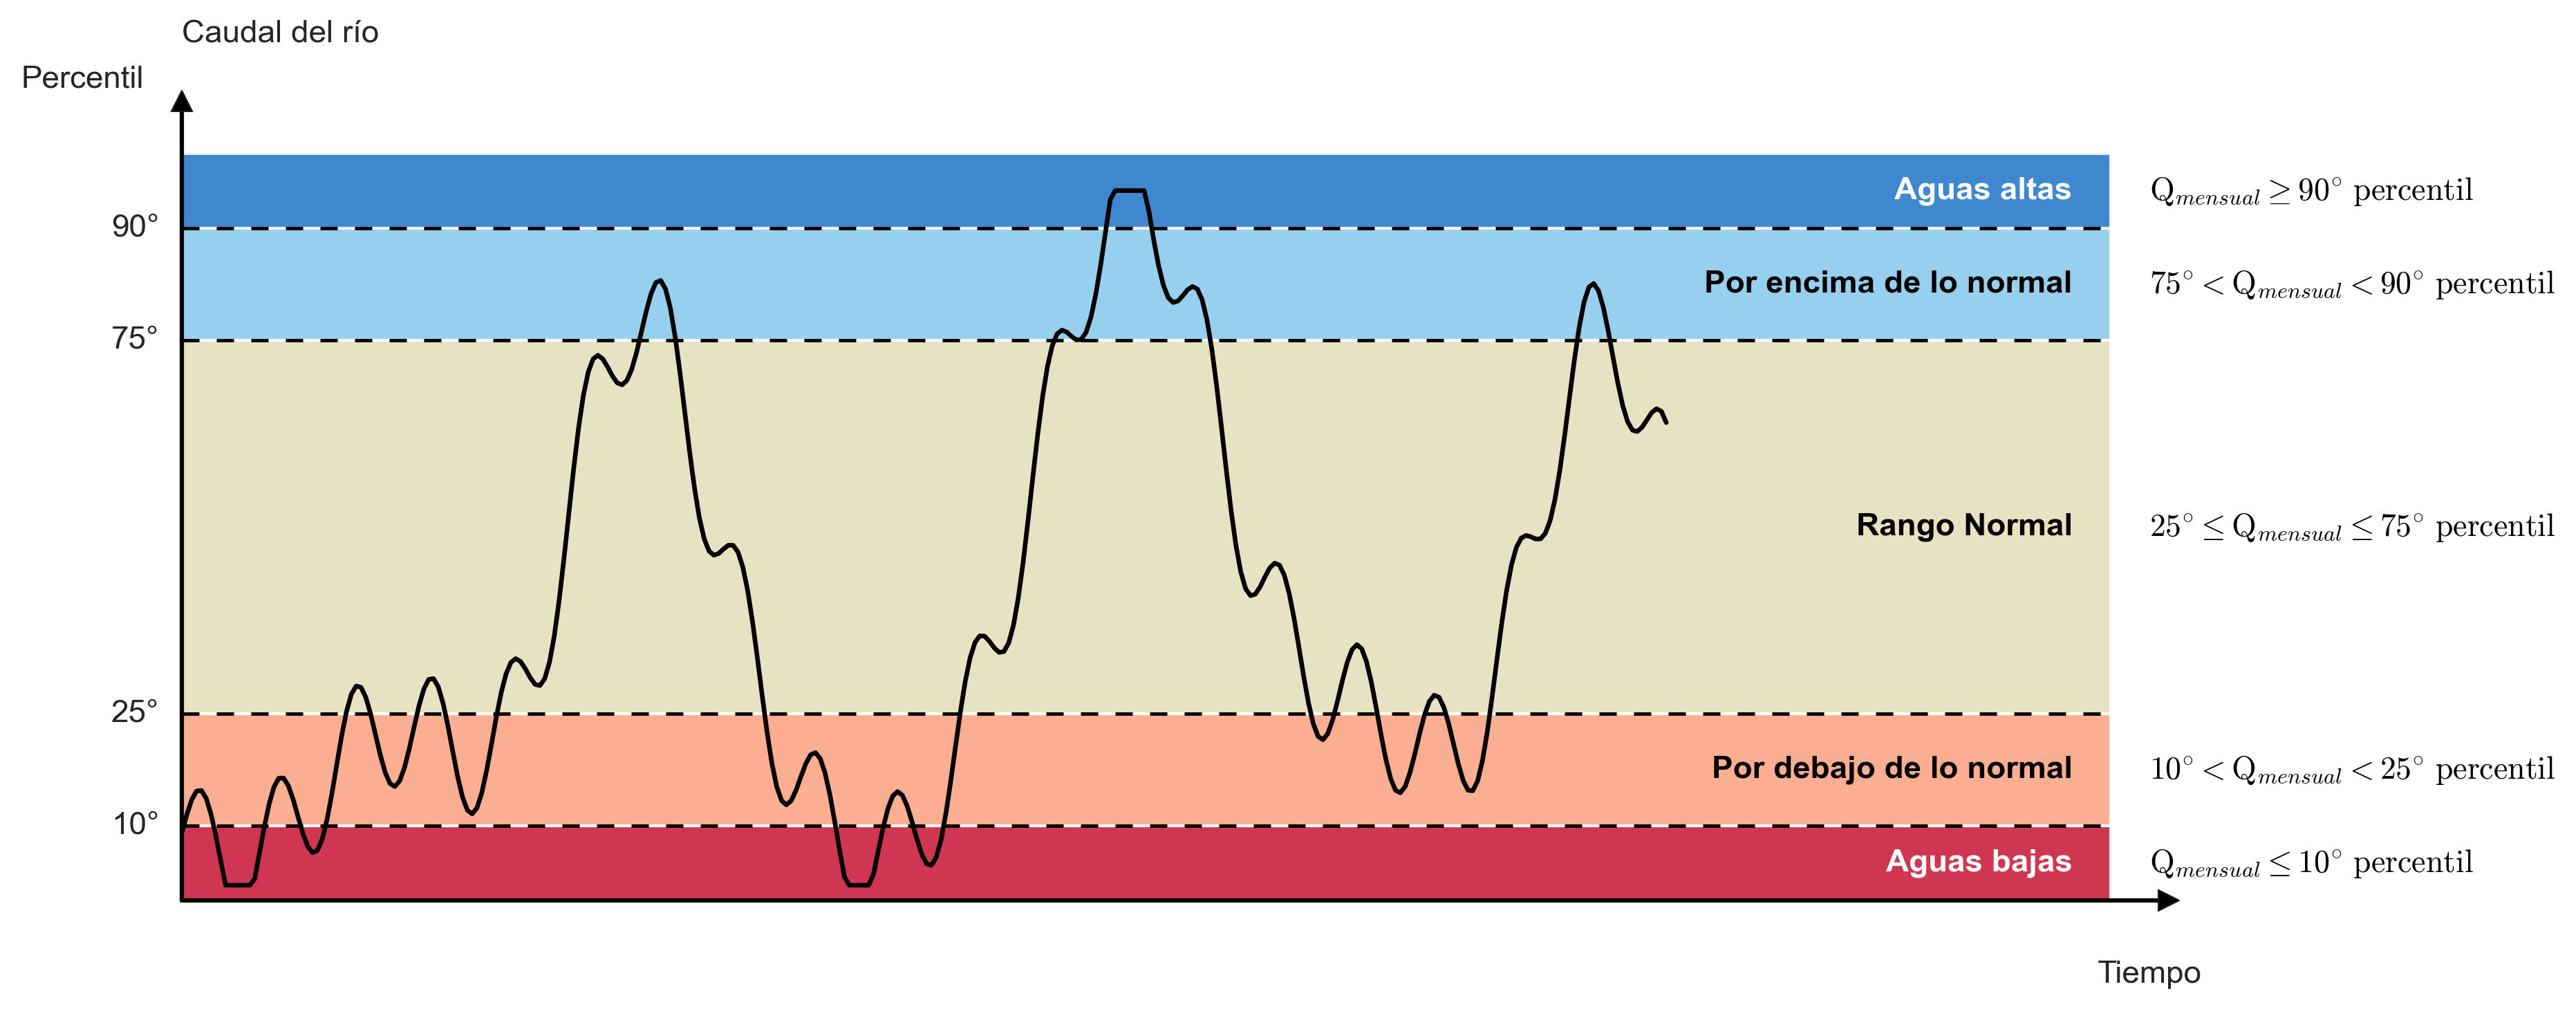

In [40]:
# 1. Grafica explicación estado hidrológico
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuración de la figura
fig, ax = plt.subplots(figsize=(12, 4.5), dpi=300)

# Paleta definida
colors = ["#CD233F", "#FFA885", "#E7E2BC", "#8ECEEE", "#2C7DCD"]

# 2. Dibujar las franjas horizontales de percentiles
ax.axhspan(0, 10, facecolor=colors[0], alpha=0.9, zorder=1)
ax.axhspan(10, 25, facecolor=colors[1], alpha=0.9, zorder=1)
ax.axhspan(25, 75, facecolor=colors[2], alpha=0.9, zorder=1)
ax.axhspan(75, 90, facecolor=colors[3], alpha=0.9, zorder=1)
ax.axhspan(90, 100, facecolor=colors[4], alpha=0.9, zorder=1)

# 3. Líneas punteadas intermedias
for p in [10, 25, 75, 90]:
    ax.axhline(p, color="black", linestyle="--", linewidth=1.2, zorder=2)

# 4. Curva del hidrograma
np.random.seed(42)
x = np.linspace(0, 1, 400)
y = (
    5
    + 18 * np.sin(2 * np.pi * 3 * x - 0.5) ** 2
    + 65 * np.exp(-(((x - 0.23) / 0.05) ** 2))
    + 85 * np.exp(-(((x - 0.50) / 0.06) ** 2))
    + 62 * np.exp(-(((x - 0.73) / 0.05) ** 2))
    + 8 * np.sin(2 * np.pi * 25 * x)
)
y = np.clip(y, 2, 95)
mask = x <= 0.77
ax.plot(x[mask], y[mask], color="black", linewidth=1.6, zorder=4)

# 5. Textos internos y fórmulas a la derecha
text_props_int = {
    "fontsize": 11,
    "fontweight": "bold",
    "ha": "right",
    "va": "center",
    "zorder": 5,
}
formula_props = {"fontsize": 11, "ha": "left", "va": "center"}

categories = [
    (
        5,
        "Aguas bajas",
        r"$\mathrm{Q}_{mensual} \leq 10^{\circ}\ \mathrm{percentil}$",
        "white",
    ),
    (
        17.5,
        "Por debajo de lo normal",
        r"$10^{\circ} < \mathrm{Q}_{mensual} < 25^{\circ}\ \mathrm{percentil}$",
        "black",
    ),
    (
        50,
        "Rango Normal",
        r"$25^{\circ} \leq \mathrm{Q}_{mensual} \leq 75^{\circ}\ \mathrm{percentil}$",
        "black",
    ),
    (
        82.5,
        "Por encima de lo normal",
        r"$75^{\circ} < \mathrm{Q}_{mensual} < 90^{\circ}\ \mathrm{percentil}$",
        "black",
    ),
    (
        95,
        "Aguas altas",
        r"$\mathrm{Q}_{mensual} \geq 90^{\circ}\ \mathrm{percentil}$",
        "white",
    ),
]

for y_pos, label, formula, text_color in categories:
    ax.text(
        0.98,
        y_pos,
        label,
        color=text_color,
        fontdict=text_props_int,
        transform=ax.get_yaxis_transform(),
    )
    ax.text(1.02, y_pos, formula, color="black", fontdict=formula_props)

# 6. Configurar límites
ax.set_xlim(0, 1)
ax.set_ylim(0, 100)

# 7. Trazar líneas explícitas para los ejes X e Y por encima de todo (zorder=10)
# Eje Y que sobresale hacia arriba hasta y=107
ax.plot([0, 0], [0, 107], color="black", linewidth=1.5, clip_on=False, zorder=10)
# Flecha eje Y
ax.plot(
    0,
    107,
    marker="^",
    color="black",
    markersize=7,
    clip_on=False,
    zorder=10,
)

# Eje X que sobresale hacia la derecha hasta x=1.03
ax.plot([0, 1.03], [0, 0], color="black", linewidth=1.5, clip_on=False, zorder=10)
# Flecha eje X
ax.plot(
    1.03,
    0,
    marker=">",
    color="black",
    markersize=7,
    clip_on=False,
    zorder=10,
)

# 8. Ocultar los spines por defecto
for spine in ax.spines.values():
    spine.set_visible(False)

# 9. Ticks y etiquetas de los ejes
ax.set_yticks([10, 25, 75, 90])
ax.set_yticklabels(["10°", "25°", "75°", "90°"], fontsize=11)
ax.tick_params(axis="y", which="both", length=4, width=1.2, direction="out")
ax.set_xticks([])

# Etiquetas "Percentil", "Caudal del río" y "Tiempo"
ax.text(-0.02, 108, "Percentil", fontsize=11, ha="right", va="bottom")
ax.text(0.0, 114, "Caudal del río", fontsize=11, ha="left", va="bottom")
ax.text(1.02, -8, "Tiempo", fontsize=11, ha="center", va="top")

# Guardar en alta definición y mostrar
# plt.savefig("esquema_percentiles.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

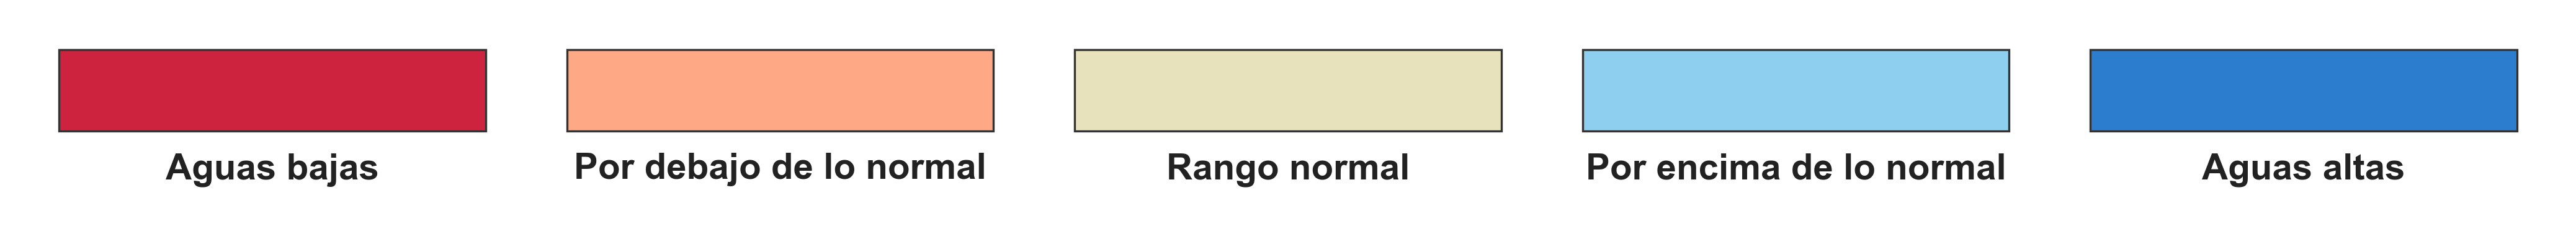

In [38]:
# 2. Definición de cinco (5) categorías y colores
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# 1. Definición de categorías y colores
categories = [
    ("Aguas bajas", "#CD233F"),
    ("Por debajo de lo normal", "#FFA885"),
    ("Rango normal", "#E7E2BC"),
    ("Por encima de lo normal", "#8ECEEE"),
    ("Aguas altas", "#2C7DCD"),
]

# 2. Configurar la figura horizontal tipo barra de simbología
fig, ax = plt.subplots(figsize=(14, 1.4), dpi=300)
ax.set_xlim(0, len(categories))
ax.set_ylim(0, 1)
ax.axis("off")

# 3. Dibujar cajas de color y nombres
for i, (nombre, color) in enumerate(categories):
    # Cuadro de color con borde sutil
    rect = mpatches.Rectangle(
        (i + 0.08, 0.42),
        0.84,
        0.42,
        facecolor=color,
        edgecolor="#333333",
        linewidth=0.8,
        transform=ax.transData,
    )
    ax.add_patch(rect)

    # Nombre de la categoría centrado debajo
    ax.text(
        i + 0.5,
        0.22,
        nombre,
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color="#222222",
    )

# 4. Guardar imagen
plt.tight_layout()
'''
plt.savefig(
    "simbologia_percentiles.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
'''
plt.show()

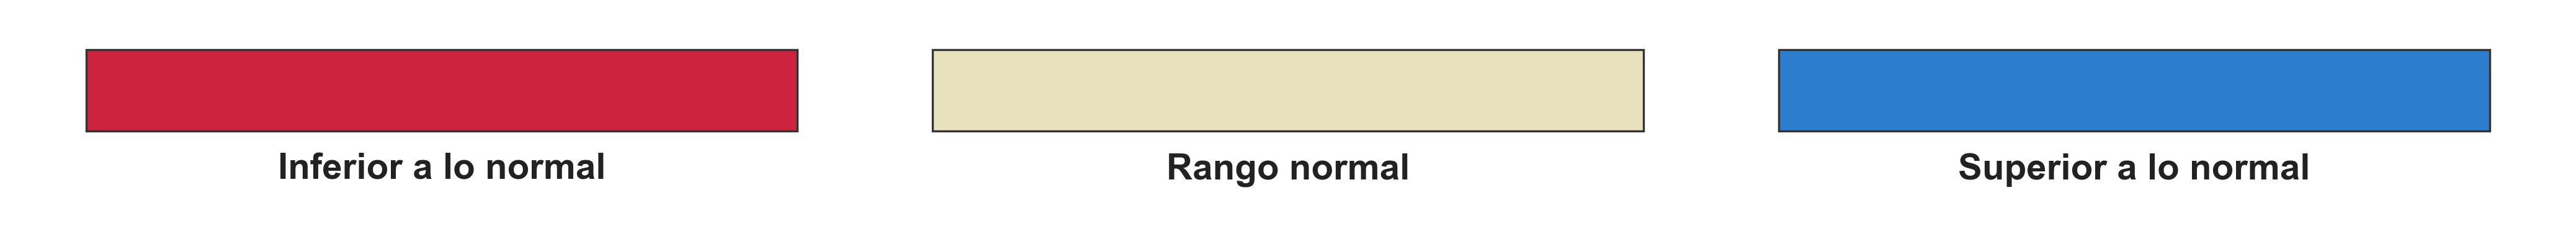

In [39]:
# 3. Definición de tres (3) categorías y colores
categories = [
    ("Inferior a lo normal", "#CD233F"),
    ("Rango normal", "#E7E2BC"),
    ("Superior a lo normal", "#2C7DCD"),
]

# 2. Configurar la figura horizontal tipo barra de simbología
fig, ax = plt.subplots(figsize=(14, 1.4), dpi=300)
ax.set_xlim(0, len(categories))
ax.set_ylim(0, 1)
ax.axis("off")

# 3. Dibujar cajas de color y nombres
for i, (nombre, color) in enumerate(categories):
    # Cuadro de color con borde sutil
    rect = mpatches.Rectangle(
        (i + 0.08, 0.42),
        0.84,
        0.42,
        facecolor=color,
        edgecolor="#333333",
        linewidth=0.8,
        transform=ax.transData,
    )
    ax.add_patch(rect)

    # Nombre de la categoría centrado debajo
    ax.text(
        i + 0.5,
        0.22,
        nombre,
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color="#222222",
    )

# 4. Guardar imagen
plt.tight_layout()
'''
plt.savefig(
    "simbologia_percentiles.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
'''
plt.show()